In [107]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))  # go up to project root
from pydantic import BaseModel
from typing import Literal
from user_profile.schema import SearchParams, State, UserProfile, VideoInfo
from prompts import orchestrator_prompt, search_prompt, relevance_prompt, transcript_prompt
import os
from langchain_deepseek import ChatDeepSeek
from IPython.display import Image, display
from tools import rapidapi_youtube
import unicodedata

In [19]:
from langgraph.graph import StateGraph, MessagesState, END, START
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver

In [6]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "language-learning-agent"

In [7]:
class ExecuteIntent(BaseModel):
    """Call this to execute the user's intent"""
    intent: Literal[
        "full_search",
        "transcript_only", 
        "rerank_only",
        "profile_update",
        "out_of_scope"
    ]
    search_params: SearchParams | None = None
    video_id: str | None = None

In [9]:
model = ChatDeepSeek(
    model = "deepseek-chat",
    temperature=0.5
)

In [47]:
test = model.invoke([HumanMessage(content="Hello, how are you?")])

In [93]:
def orchestrator(state : State, config : RunnableConfig, store : BaseStore):
    
    # # Get the user id
    user_id = config["configurable"]["user_id"]

    # # Retrieve the user state from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None

    system_msg = orchestrator_prompt.PROMPT.format(user_profile=user_profile)

    response = model.bind_tools([ExecuteIntent], tool_choice="ExecuteIntent").invoke([SystemMessage(content=system_msg)] + state["messages"])
    
    if response.tool_calls:
        args = response.tool_calls[0]["args"]  # reading what LLM generated
        search_params = args.get("search_params", None)  # getting the specific field
        if len(search_params["language"]) > 2:
            raise ValueError("Language code should be used in the search parameters, not the language name")

        video_id = args.get("video_id", None)
    else:
        search_params = None
        video_id = None

    return {"messages" : [response], "search_params": search_params, "video_id" : video_id}

Testing the Orchestrator

In [ ]:
from unittest.mock import MagicMock
config = {"configurable": {"user_id": "test_user"}}
    
store = MagicMock()
store.search.return_value = []  # empty profile

# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me German cooking videos at B1")],
    "search_params": None,
    "videos": None,
    "user_profile": None
}

result = orchestrator(state, config, store)
print(result["search_params"])

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 1037, 'total_tokens': 1118, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': '290cd629-7f16-4305-9df1-46a65e4c55bf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cda8d-0f81-7f33-aacf-521cf75b6136-0', tool_calls=[{'name': 'ExecuteIntent', 'args': {'intent': 'full_search', 'search_params': {'topic': 'cooking', 'language': 'German', 'target_level': 'B1', 'max_results': 10}}, 'id': 'call_00_OjDtdB85oRskiCSTtsUL70F2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1037, 'output_tokens': 81, 'total_tokens': 1118, 'input_token_details': {'cache_read

In [55]:
result["search_params"]

{'topic': 'cooking',
 'language': 'German',
 'target_level': 'B1',
 'max_results': 10}

In [120]:
def search_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for searching videos based on the user's preferences and the search parameters generated by the orchestrator.
    # # Get the user id
    user_id = config["configurable"]["user_id"]

    # # Retrieve the user state from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None
    
    # Get the search parameters from state
    search_params = state["search_params"]
    system_msg = search_prompt.PROMPT.format(search_params=search_params, user_profile=user_profile)

    # Use the LLM to generate a query
    response = model.invoke([SystemMessage(content=system_msg)])
    query = (response.content).split("\n")[0]
    
    # Keep only ASCII characters
    normalized = unicodedata.normalize("NFD", query)
    query = "".join(c for c in normalized if unicodedata.category(c) != "Mn")

    print("Generated query:", query)
    print("Language code:", search_params["language"])
    print("Max results:", search_params["max_results"])

    # Call the search tool with the generated query
    search_results = rapidapi_youtube.search_youtube(
        query=query,
        language=search_params["language"],
        max_results=search_params["max_results"]
    )

    # Filter the search results to only include one video per channel
    seen_channels = set()
    videos = []
    for video in search_results:
        if video.channel_title not in seen_channels:
            seen_channels.add(video.channel_title)
            videos.append(video)

    # This agent only updates the videos field in the state.
    return {"videos": videos}

Testing the Search Agent

In [121]:
import importlib
importlib.reload(search_prompt)
importlib.reload(rapidapi_youtube)

<module 'tools.rapidapi_youtube' from '/home/renan-florencio/Documents/language-learning-agent/tools/rapidapi_youtube.py'>

In [122]:
from unittest.mock import MagicMock
config = {"configurable": {"user_id": "test_user"}}
    
store = MagicMock()
store.search.return_value = []  # empty profile

# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me French cooking videos at B1")],
    "search_params": {
        'topic': 'cooking',
        'language': 'fr',
        'target_level': 'B1',
        'max_results': 10
        },
    "videos": None,
    "user_profile": None
}

result = search_agent(state, config, store)
print(result["videos"])

Generated query: cuisine recettes francaises faciles
Language code: fr
Max results: 10
[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=206664, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='kM1ff5bJAhE', title='Petits Pois A La Viande et Aux Pommes de Terre', channel_id='UC-izX-l01iPFN3ycEiaKe3A', channel_title="Noelia's Cooking", CC=False, published_time='il y a 1 an', views=755667, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189164, detected_language=None, detected

In [14]:
def transcript_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for generating transcripts for videos that are found to be relevant to the user's preferences.
    pass

In [16]:
def scoring_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for scoring the relevance of videos to the user's preferences based on the transcripts and other metadata.
    pass

In [17]:
def profile_update_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for updating the user's profile based on their interactions and feedback.
    pass

In [18]:
def route_intent(state: State) -> Literal[END, "search_agent", "transcript_agent", "scoring_agent", "profile_update_node"]:
    last_message = state["messages"][-1]
    if len(last_message.tool_calls) == 0:
        return END
    intent = last_message.tool_calls[0]["args"]["intent"] 
    if intent == "full_search":
        return "search_agent"
    elif intent == "transcript_only":
        return "transcript_agent"
    elif intent == "rerank_only":
        return "scoring_agent"
    elif intent == "profile_update":
        return "profile_update_node"
    else:
        return END

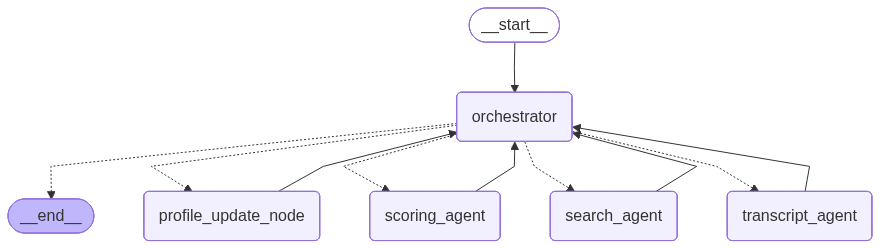

In [22]:
builder = StateGraph(State)
builder.add_node("orchestrator", orchestrator)
builder.add_node("search_agent", search_agent)
builder.add_node("transcript_agent", transcript_agent)
builder.add_node("scoring_agent", scoring_agent)
builder.add_node("profile_update_node", profile_update_agent)
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", route_intent)
builder.add_edge("search_agent", "orchestrator")
builder.add_edge("transcript_agent", "orchestrator")
builder.add_edge("scoring_agent", "orchestrator")
builder.add_edge("profile_update_node", "orchestrator")

# Store long-term
across_thread_memory = InMemoryStore()

# Store short-term
in_thread_memory = MemorySaver()

graph = builder.compile(checkpointer=in_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))